# 2.2.3 指数对数与链式法则

## 学习目标与先修知识

能解释指数函数（exponential function）、自然对数（natural logarithm）和简单链式法则（chain rule），计算指数衰减曲线的变化率，并检查指数里的量纲（dimension）。

先修：前两节的极限（limit）、导数（derivative）、定积分（definite integral）及中学幂运算。 [复习上一节](02-从矩形累积到定积分.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

固定时间内反复做“按当前量的一小部分变化”，为什么会出现指数曲线？怎样验证 exp(−kt) 的变化率与自身成比例？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
rows=[(n,(1+1/n)**n) for n in [1,2,10,100,1000]]
display(Markdown(show_table(['分成 n 份','(1+1/n)^n'],rows)))
print('math.e =',math.e)

| 分成 n 份 | (1+1/n)^n |
| --- | --- |
| 1 | 2 |
| 2 | 2.25 |
| 10 | 2.59374 |
| 100 | 2.70481 |
| 1000 | 2.71692 |

math.e = 2.718281828459045


## 模型假设

先讨论无量纲（dimensionless）数学变量 x。自然常数 $e\approx2.71828$ 可由 $(1+1/n)^n$ 的极限得到，$\exp(x)=e^x$。用于所追踪物质总量（tracked amount）时，再写为 $A_0\exp(-kt)$，k 用 1/T、t 用 T，故 kt 无量纲。

## 数学解释与推导

指数函数满足 $e^{x+y}=e^x e^y$，并有 $\lim_{h\to0}(e^h-1)/h=1$。利用差商（difference quotient），
$$\frac{e^{x+h}-e^x}{h}=e^x\frac{e^h-1}{h}\longrightarrow e^x.$$
因此 $d(e^x)/dx=e^x$。这里利用指数极限，将差商的极限转化为导数。

**内层也在变。** 对复合函数 $F(g(t))$，一个小变化先成为 $\Delta g\approx g'(t)\Delta t$，再成为 $\Delta F\approx F'(g(t))\Delta g$，故链式法则为
$$\frac{dF(g(t))}{dt}=F'(g(t))g'(t).$$
取 $F(x)=e^x$、$g(t)=-kt$，得到 $d(e^{-kt})/dt=-ke^{-kt}$。负号决定衰减方向；遗漏 k 就错了时间尺度（time scale）。

自然对数 $\ln x$ 是正数上的指数反函数：$\ln(e^x)=x$、$e^{\ln x}=x$，且 $\ln(ab)=\ln a+\ln b$。对 $e^{\ln x}=x$ 用链式法则得 $x(\ln x)'=1$，所以 $(\ln x)'=1/x$。于是 $\int dx/x=\ln|x|+C$（区间不能穿过零）。

常数 C 的导数为零。要从变化率恢复一条特定曲线，必须由初值（initial condition）确定 C。以 $A'=2t$ 为例，$A=t^2+C$；A(0)=3 才给出 C=3。后面的一阶方程求解会反复使用这些关系。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def exponential_pair(k, times):
    import math
    values = [math.exp(-k * t) for t in times]
    derivatives = [-k * value for value in values]
    return values, derivatives

## 对照实验

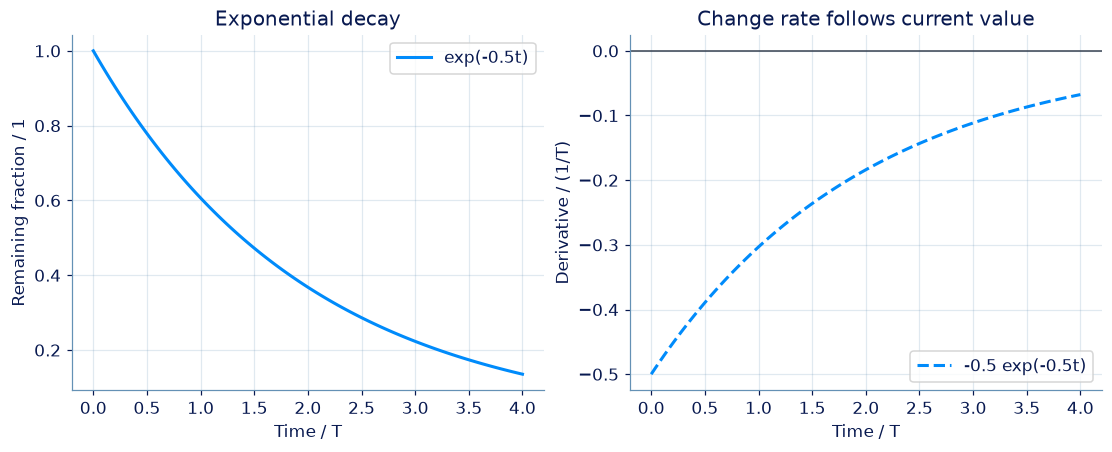

In [4]:
times=np.linspace(0,4,101)
values,derivatives=exponential_pair(.5,times)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].plot(times,values,label='exp(-0.5t)');axes[0].set(xlabel='Time / T',ylabel='Remaining fraction / 1',title='Exponential decay');axes[0].legend()
axes[1].plot(times,derivatives,'--',label='-0.5 exp(-0.5t)');axes[1].axhline(0,color='#384251',lw=1)
axes[1].set(xlabel='Time / T',ylabel='Derivative / (1/T)',title='Change rate follows current value');axes[1].legend()
plt.show()

## 结果解释

衰减曲线越接近零，负变化率的绝对值越小。在 t=0 处剩余比例为 1，变化率为 −0.5/T；到 t=2 T，比例为 exp(−1)。这与“每个 T 固定扣掉 0.5”是不同规则。

### 独立核对

这里的中心差分（central difference）只提供数值核对，导数关系的数学依据仍是前面的推导；检查零系数则验证常数函数分支。

In [5]:
for t in [0,1,2,4]:
    eps=1e-5
    numerical=(math.exp(-.5*(t+eps))-math.exp(-.5*(t-eps)))/(2*eps)
    assert math.isclose(numerical,-.5*math.exp(-.5*t),abs_tol=1e-10)
for x in [.2,1,4]:
    assert math.isclose(math.exp(math.log(x)),x)
values,derivatives=exponential_pair(0,[0,1,5])
assert values==[1,1,1] and derivatives==[0,0,0]
print('中心差分核对链式导数、指数对数互逆和零系数边界。')

中心差分核对链式导数、指数对数互逆和零系数边界。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：指数里的单位

用 A(t)=A0 exp(−kt) 描述人工清除。t 的单位是 T。哪些判断成立？

- **A.** k 的单位应为 1/T。
- **B.** −kt 是无量纲（dimensionless）数。
- **C.** 把秒换成分钟后可直接保留 k 的原数值。
- **D.** exp(0)=1，因此满足 A(0)=A0。

[作答：指数里的单位](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-exponent-unit)

### 第 2 题 · Python 计算题：给衰减曲线和变化率配对

计算无量纲（dimensionless）函数 f(t)=exp(−kt) 及其导数（derivative） f′(t)=−k exp(−kt)。导数结果用于核对曲线局部变化，不用有限差分（finite difference）近似。

**函数与代码模板**

```python
def solve(
    k: float,
    times: list[float],
) -> tuple[list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `k` | `float` | 非负衰减系数。 | 1/T |
| `times` | `list[float]` | 需要求值的时刻，按原顺序返回。 | T |

**返回值**

按以下顺序返回元组：(values, derivatives)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 各时刻 f(t)。 | 1 |
| `derivatives` | `list[float]` | 各时刻 f′(t)。 | 1/T |

**计算规则**

分别构造 exp(−k*t) 与 −k*exp(−k*t) 的列表；k=0 时为常数 1、变化率 0。

**约束与边界**

- 所有数值有限；无需修改输入（input）。
- 0 ≤ k ≤ 3；0 ≤ times[i] ≤ 20；列表长度 0—1000，可重复、可不排序。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| k | 非负衰减系数。 | 0.5 | 1/T |
| times | 需要求值的时刻，按原顺序返回。 | [0, 2] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
k = 0.5
times = [0, 2]

result = solve(k, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| values | 各时刻 f(t)。 | [1.0, 0.36787944117144233] | 1 |
| derivatives | 各时刻 f′(t)。 | [-0.5, -0.18393972058572117] | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 0.36787944117144233],
                   [-0.5, -0.18393972058572117])
```

**样例解释**

t=0 时值为 1、导数 −0.5；t=2 时值为 exp(−1)，导数为该值的 −0.5 倍。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：给衰减曲线和变化率配对](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-chain-rule)

### 第 3 题 · 单项选择题：遗漏了哪个因子

某人把 d[exp(−2t)]/dt 写成 exp(−2t)。正确修正是什么？

- **A.** 乘 −2。
- **B.** 乘 t。
- **C.** 除以 exp(−2t)。
- **D.** 不需要修正。

[作答：遗漏了哪个因子](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-chain-factor)

### 第 4 题 · 多项选择题：相同导数为何还有不同曲线

在同一区间内，A′(t)=2t，B′(t)=2t，A(0)=1，B(0)=4。哪些结论成立？

- **A.** A 与 B 完全相同。
- **B.** B(t)−A(t)=3。
- **C.** 初值（initial condition）决定积分（definite integral）后的常数。
- **D.** A(t)=1+t²，B(t)=4+t²。

[作答：相同导数为何还有不同曲线](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-integration-constant)

**进一步阅读**

[MIT 链式法则](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/pages/1.-differentiation/part-a-definition-and-basic-rules/session-11-chain-rule/)；[指数函数及其反函数](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/pages/1.-differentiation/part-b-implicit-differentiation-and-inverse-functions/session-17-the-exponential-function-its-derivative-and-its-inverse/)。